# 차원 28*28 다 사용

In [ ]:
# 1. 라이브러리 임포트 + 랜덤 시드 고정
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)

print("셀 1 완료: 라이브러리 + 랜덤시드 설정")


셀 1 완료: 라이브러리 + 랜덤시드 설정


In [ ]:
# 2. 데이터 로드 (컬러 MNIST + FG/BG 라벨)
data = np.load("mnist_colored_fg_bg.npz")

images = data["images"]             # (60000, 28, 28, 3)
digit_labels = data["digit_labels"]
fg_labels = data["fg_labels"]
bg_labels = data["bg_labels"]

print("데이터 로드 완료")
print("images:", images.shape)
print("digit_labels:", digit_labels.shape)
print("fg_labels:", fg_labels.shape)
print("bg_labels:", bg_labels.shape)

RAINBOW_NAMES = ['RED', 'ORANGE', 'YELLOW', 'GREEN', 'BLUE', 'INDIGO', 'VIOLET']


데이터 로드 완료
images: (60000, 28, 28, 3)
digit_labels: (60000,)
fg_labels: (60000,)
bg_labels: (60000,)


In [ ]:
# 3. 정규화(0~1) + flatten + 7:2:1 split

# 0~255 → 0~1
images_float = images.astype(np.float32) / 255.0
N, H, W, C = images_float.shape

# (N, 2352)로 펼치기
X_all_flat = images_float.reshape(N, -1)
y_fg_all = fg_labels
y_bg_all = bg_labels

print("Flatten 완료:", X_all_flat.shape)

# ---- Train 70%, Temp 30% ----
X_img_train, X_img_temp, X_flat_train, X_flat_temp, fg_train, fg_temp, bg_train, bg_temp = train_test_split(
    images_float, X_all_flat, y_fg_all, y_bg_all,
    test_size=0.3, random_state=42, stratify=y_fg_all
)

# ---- Temp(30%) → Valid 20%, Test 10% ----
X_img_valid, X_img_test, X_flat_valid, X_flat_test, fg_valid, fg_test, bg_valid, bg_test = train_test_split(
    X_img_temp, X_flat_temp, fg_temp, bg_temp,
    test_size=1/3, random_state=42, stratify=fg_temp
)

print("Train:", X_flat_train.shape)
print("Valid:", X_flat_valid.shape)
print("Test :", X_flat_test.shape)


Flatten 완료: (60000, 2352)
Train: (42000, 2352)
Valid: (12000, 2352)
Test : (6000, 2352)


In [ ]:
# 4. StandardScaler 적용 (PCA 없이 원 특징 그대로 사용)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_flat_train)
X_valid = scaler.transform(X_flat_valid)
X_test  = scaler.transform(X_flat_test)

print("스케일링 완료")
print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)
print("Test  shape:", X_test.shape)


스케일링 완료
Train shape: (42000, 2352)
Valid shape: (12000, 2352)
Test  shape: (6000, 2352)


In [ ]:
# 5. 5개 모델 정의

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, n_jobs=-1, random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=40, random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5, n_jobs=-1
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=200, C=1.0, solver='lbfgs', multi_class='multinomial', n_jobs=-1
    ),
    "Linear SVM": LinearSVC(
        C=1.0, max_iter=2000, random_state=42
    )
}

print("모델 준비 완료")


모델 준비 완료


In [ ]:
# 6. 각 모델 학습(FG/BG) + valid/test 성능 측정

results = []
fg_models = {}
bg_models = {}

for name, base_model in models.items():
    print("\n" + "="*60)
    print(f"▶ 모델: {name}")
    print("="*60)

    # ---- FG 학습 ----
    fg_clf = base_model.__class__(**base_model.get_params())
    fg_clf.fit(X_train, fg_train)
    fg_valid_pred = fg_clf.predict(X_valid)
    fg_test_pred  = fg_clf.predict(X_test)
    fg_valid_acc = accuracy_score(fg_valid, fg_valid_pred)
    fg_test_acc  = accuracy_score(fg_test, fg_test_pred)

    # ---- BG 학습 ----
    bg_clf = base_model.__class__(**base_model.get_params())
    bg_clf.fit(X_train, bg_train)
    bg_valid_pred = bg_clf.predict(X_valid)
    bg_test_pred  = bg_clf.predict(X_test)
    bg_valid_acc = accuracy_score(bg_valid, bg_valid_pred)
    bg_test_acc  = accuracy_score(bg_test, bg_test_pred)

    print(f"[FG] valid={fg_valid_acc:.4f}, test={fg_test_acc:.4f}")
    print(f"[BG] valid={bg_valid_acc:.4f}, test={bg_test_acc:.4f}")

    fg_models[name] = fg_clf
    bg_models[name] = bg_clf

    results.append({
        "Model": name,
        "FG Valid (%)": fg_valid_acc * 100,
        "FG Test (%)":  fg_test_acc * 100,
        "BG Valid (%)": bg_valid_acc * 100,
        "BG Test (%)":  bg_test_acc * 100
    })

results_df = pd.DataFrame(results)
print("\n===== 최종 성능 비교표 =====")
print(results_df.to_string(index=False))



▶ 모델: Random Forest
[FG] valid=0.9998, test=1.0000
[BG] valid=1.0000, test=1.0000

▶ 모델: Decision Tree
[FG] valid=0.9916, test=0.9908
[BG] valid=1.0000, test=1.0000

▶ 모델: KNN
[FG] valid=0.7590, test=0.7568
[BG] valid=1.0000, test=1.0000

▶ 모델: Logistic Regression
[FG] valid=0.9813, test=0.9823
[BG] valid=1.0000, test=1.0000

▶ 모델: Linear SVM
[FG] valid=0.9237, test=0.9225
[BG] valid=0.9958, test=0.9957

===== 최종 성능 비교표 =====
              Model  FG Valid (%)  FG Test (%)  BG Valid (%)  BG Test (%)
      Random Forest     99.983333   100.000000       100.000   100.000000
      Decision Tree     99.158333    99.083333       100.000   100.000000
                KNN     75.900000    75.683333       100.000   100.000000
Logistic Regression     98.133333    98.233333       100.000   100.000000
         Linear SVM     92.375000    92.250000        99.575    99.566667



==== Random Forest FG Classification Report ====
              precision    recall  f1-score   support

         RED       1.00      1.00      1.00       859
      ORANGE       1.00      1.00      1.00       860
      YELLOW       1.00      1.00      1.00       838
       GREEN       1.00      1.00      1.00       853
        BLUE       1.00      1.00      1.00       877
      INDIGO       1.00      1.00      1.00       854
      VIOLET       1.00      1.00      1.00       859

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000


==== Random Forest BG Classification Report ====
              precision    recall  f1-score   support

         RED       1.00      1.00      1.00       875
      ORANGE       1.00      1.00      1.00       865
      YELLOW       1.00      1.00      1.00       819
       GREEN       1.00      1.00      1.00       864
        BLUE       1.00      1.0

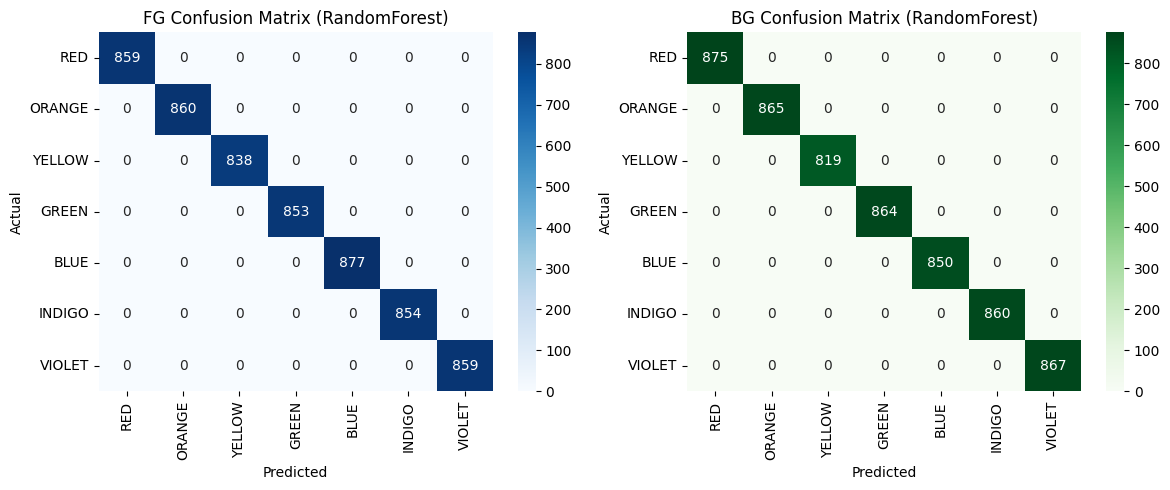

In [ ]:
# 7. Random Forest 상세 분석

rf_fg = fg_models["Random Forest"]
rf_bg = bg_models["Random Forest"]

rf_fg_test_pred = rf_fg.predict(X_test)
rf_bg_test_pred = rf_bg.predict(X_test)

print("\n==== Random Forest FG Classification Report ====")
print(classification_report(fg_test, rf_fg_test_pred, target_names=RAINBOW_NAMES))

print("\n==== Random Forest BG Classification Report ====")
print(classification_report(bg_test, rf_bg_test_pred, target_names=RAINBOW_NAMES))

cm_fg = confusion_matrix(fg_test, rf_fg_test_pred)
cm_bg = confusion_matrix(bg_test, rf_bg_test_pred)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_fg, annot=True, fmt="d", cmap="Blues",
            xticklabels=RAINBOW_NAMES, yticklabels=RAINBOW_NAMES)
plt.title("FG Confusion Matrix (RandomForest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
sns.heatmap(cm_bg, annot=True, fmt="d", cmap="Greens",
            xticklabels=RAINBOW_NAMES, yticklabels=RAINBOW_NAMES)
plt.title("BG Confusion Matrix (RandomForest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()



샘플 시각화 시작...


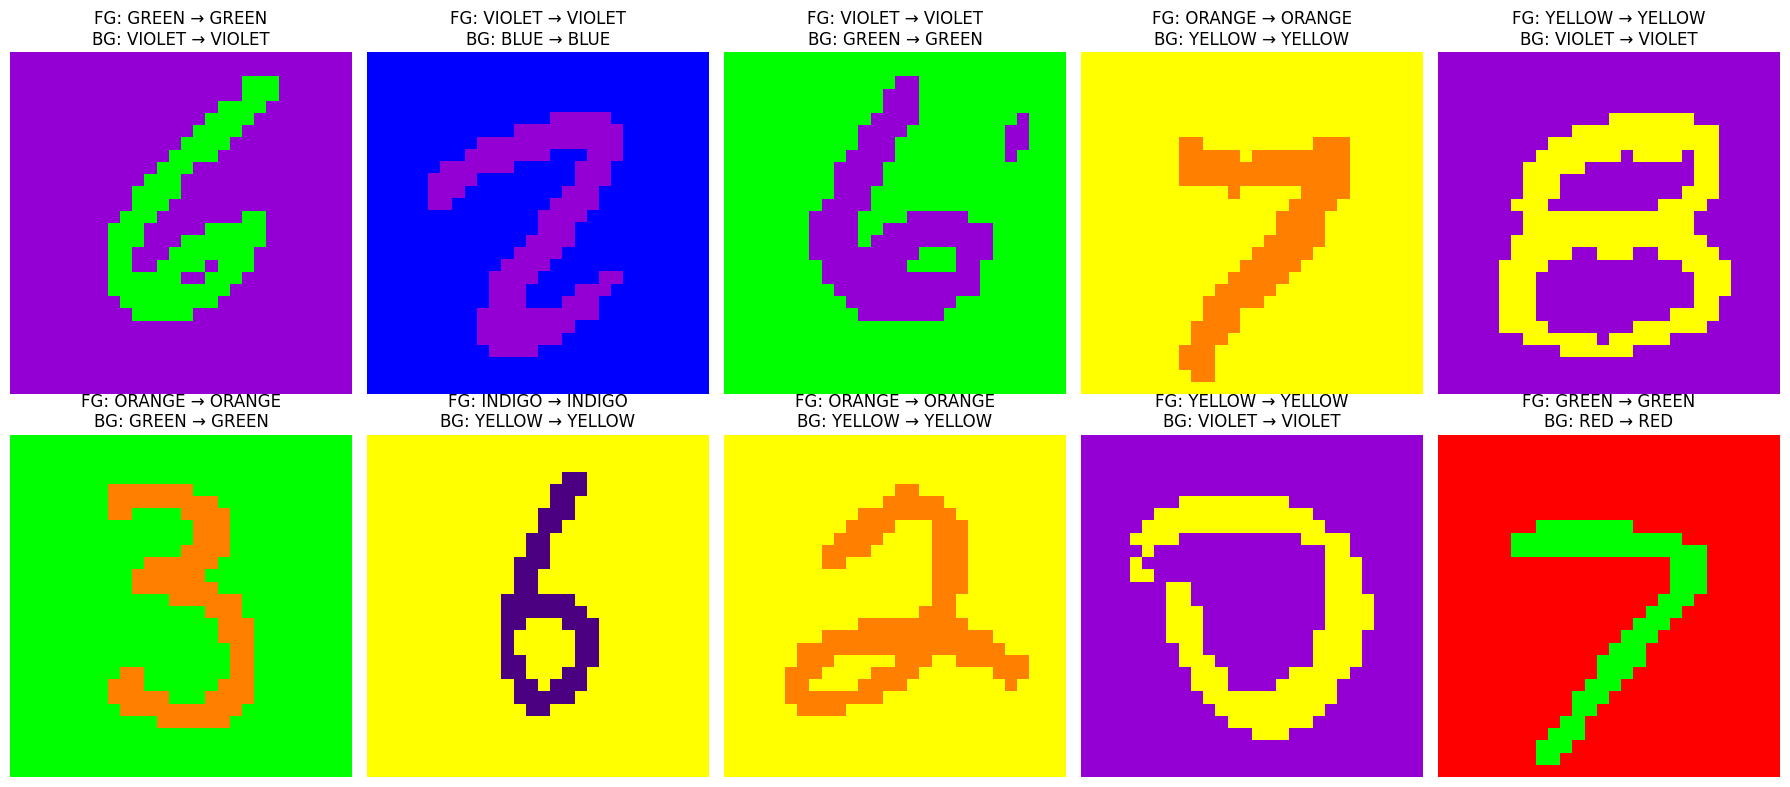

In [ ]:
# 8. 예측 샘플 시각화 (Random Forest)

print("\n샘플 시각화 시작...")

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
sample_indices = np.random.choice(len(X_img_test), 10, replace=False)

for ax, idx in zip(axes.flat, sample_indices):
    ax.imshow(X_img_test[idx])
    ax.axis("off")

    true_fg = RAINBOW_NAMES[fg_test[idx]]
    pred_fg = RAINBOW_NAMES[rf_fg_test_pred[idx]]

    true_bg = RAINBOW_NAMES[bg_test[idx]]
    pred_bg = RAINBOW_NAMES[rf_bg_test_pred[idx]]

    ax.set_title(f"FG: {true_fg} → {pred_fg}\nBG: {true_bg} → {pred_bg}")

plt.tight_layout()
plt.show()


# **아래는 안 봐도 됨! (정확도 더 떨어져서 폐기)

# FG/BG 분류(6만장)
PCA로 2352차원 → 100차원 축소



라이브러리 및 랜덤 시드 설정 완료
데이터 로드 완료
images: (60000, 28, 28, 3)
digit_labels: (60000,)
fg_labels: (60000,)
bg_labels: (60000,)
특징량 차원: 2352
Train: (42000, 2352) (42000,)
Valid: (12000, 2352) (12000,)
Test : (6000, 2352) (6000,)
PCA 완료:  100 차원
모델 정의 완료

▶ 모델: Random Forest
[FG] valid acc: 0.9932, test acc: 0.9937
[BG] valid acc: 1.0000, test acc: 1.0000

▶ 모델: Decision Tree
[FG] valid acc: 0.9848, test acc: 0.9815
[BG] valid acc: 0.9999, test acc: 1.0000

▶ 모델: KNN
[FG] valid acc: 0.8728, test acc: 0.8755
[BG] valid acc: 1.0000, test acc: 1.0000

▶ 모델: Logistic Regression
[FG] valid acc: 0.9835, test acc: 0.9828
[BG] valid acc: 1.0000, test acc: 1.0000

▶ 모델: Linear SVM
[FG] valid acc: 0.9467, test acc: 0.9507
[BG] valid acc: 1.0000, test acc: 1.0000

최종 성능 비교 (전경/후경, Valid/Test Accuracy, %)
              Model  FG valid (%)  FG test (%)  BG valid (%)  BG test (%)
      Random Forest     99.325000    99.366667    100.000000        100.0
      Decision Tree     98.483333    98.150000     99.99

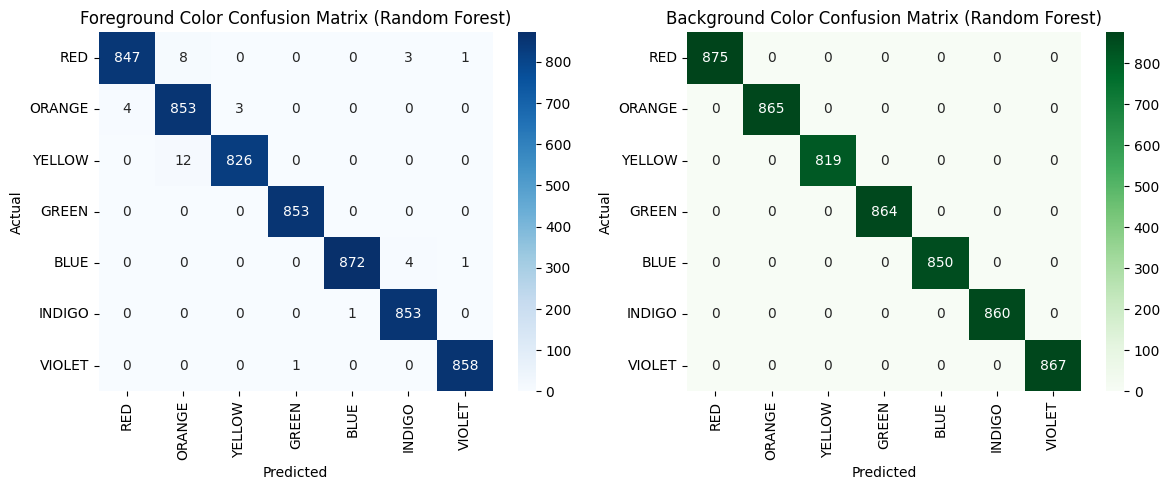


샘플 예측 결과 시각화 (Random Forest, Test 셋 기준)


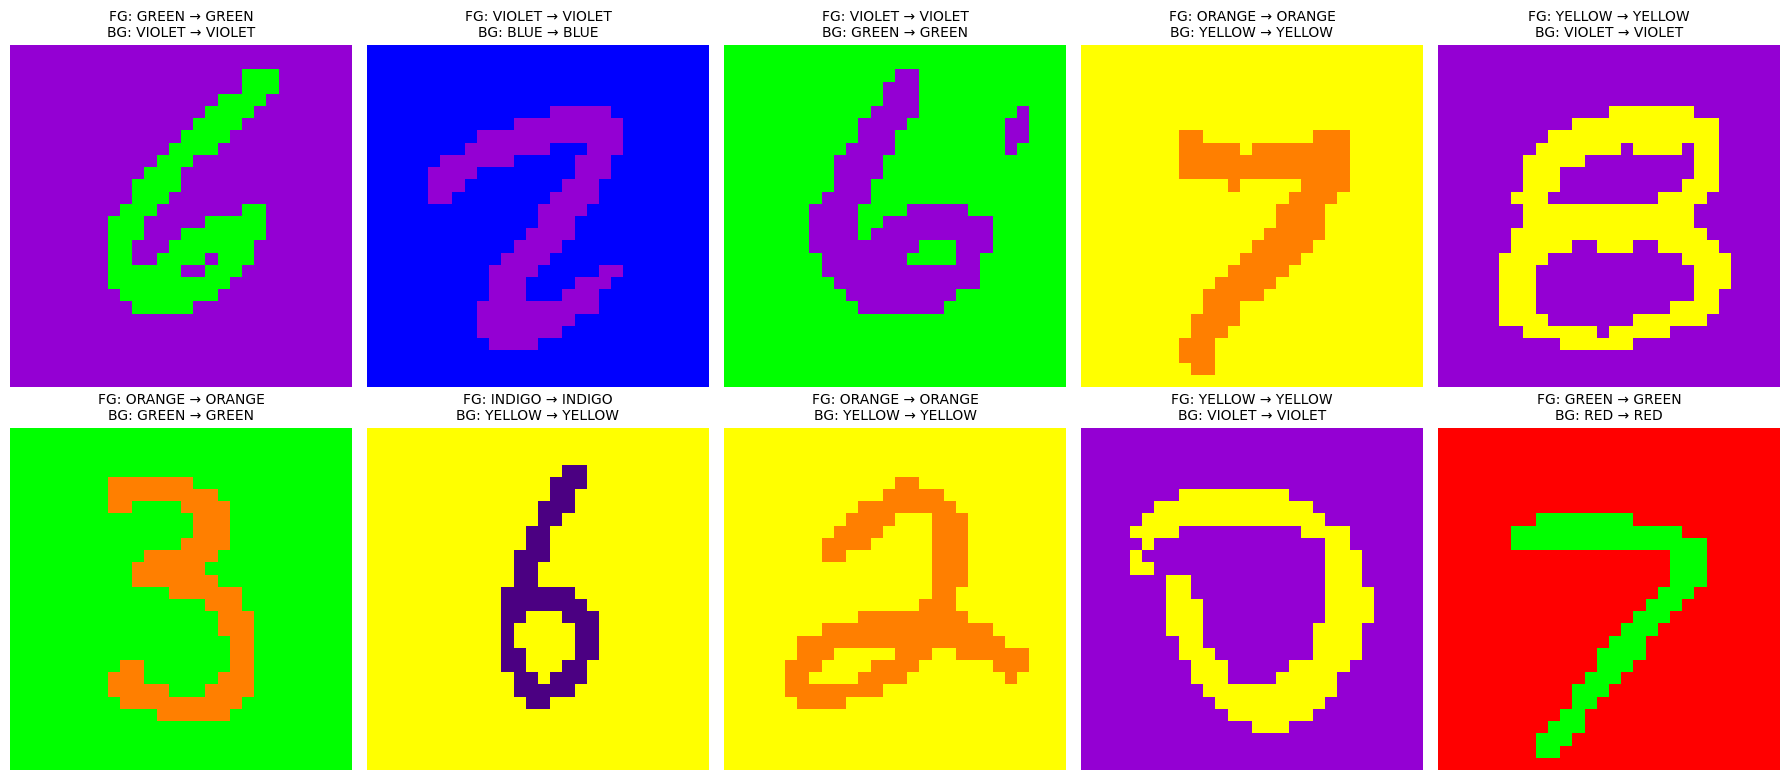

In [ ]:
# ============================================
# 0. 라이브러리 임포트 & 랜덤 시드 고정
# ============================================
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)

print("라이브러리 및 랜덤 시드 설정 완료")


# ============================================
# 1. 데이터 로드 (컬러 MNIST + FG/BG 라벨)
# ============================================
data_path = "mnist_colored_fg_bg.npz"  # 필요시 파일명만 바꿔주면 됨
data = np.load(data_path)

images = data['images']         # (60000, 28, 28, 3)
digit_labels = data['digit_labels']  # (60000,)
fg_labels = data['fg_labels']        # (60000,)
bg_labels = data['bg_labels']        # (60000,)

print("데이터 로드 완료")
print("images:", images.shape)
print("digit_labels:", digit_labels.shape)
print("fg_labels:", fg_labels.shape)
print("bg_labels:", bg_labels.shape)

# 색 이름 (라벨 0~6과 대응)
RAINBOW_NAMES = ['RED', 'ORANGE', 'YELLOW', 'GREEN', 'BLUE', 'INDIGO', 'VIOLET']


# ============================================
# 2. 입력 전처리: 정규화 + flatten
# ============================================
# 이미지는 0~255 → 0~1
images_float = images.astype(np.float32) / 255.0
N, H, W, C = images_float.shape
X_all_flat = images_float.reshape(N, -1)  # (60000, 28*28*3)

y_fg_all = fg_labels.astype(np.int32)
y_bg_all = bg_labels.astype(np.int32)

print("특징량 차원:", X_all_flat.shape[1])


# ============================================
# 3. Train / Valid / Test = 7 : 2 : 1 나누기 (인덱스 유지)
# ============================================
# 먼저 Train 70%, Temp 30%
X_img_train, X_img_temp, X_flat_train, X_flat_temp, fg_train, fg_temp, bg_train, bg_temp = train_test_split(
    images_float,
    X_all_flat,
    y_fg_all,
    y_bg_all,
    test_size=0.3,
    random_state=42,
    stratify=y_fg_all
)

# Temp(30%) → Valid(20%), Test(10%) → 비율상 test_size=1/3
X_img_valid, X_img_test, X_flat_valid, X_flat_test, fg_valid, fg_test, bg_valid, bg_test = train_test_split(
    X_img_temp,
    X_flat_temp,
    fg_temp,
    bg_temp,
    test_size=1/3,
    random_state=42,
    stratify=fg_temp
)

print("Train:", X_flat_train.shape, fg_train.shape)
print("Valid:", X_flat_valid.shape, fg_valid.shape)
print("Test :", X_flat_test.shape, fg_test.shape)


# ============================================
# 4. 스케일링 + PCA (차원 축소로 속도 개선)
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_flat_train)
X_valid_scaled = scaler.transform(X_flat_valid)
X_test_scaled  = scaler.transform(X_flat_test)

# PCA로 100차원으로 축소 (로지스틱/LinearSVM 속도 개선 목적)
pca = PCA(n_components=100, random_state=42, svd_solver='randomized')
X_train = pca.fit_transform(X_train_scaled)
X_valid = pca.transform(X_valid_scaled)
X_test  = pca.transform(X_test_scaled)

print("PCA 완료: ", X_train.shape[1], "차원")


# ============================================
# 5. 5개 모델 정의 (시간 고려 파라미터 설정)
# ============================================
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        n_jobs=-1,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=40,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=200,
        C=1.0,
        solver='lbfgs',
        multi_class='multinomial',
        n_jobs=-1
    ),
    "Linear SVM": LinearSVC(
        C=1.0,
        max_iter=2000,
        random_state=42
    )
}

print("모델 정의 완료")


# ============================================
# 6. 각 모델별 전경(FG) / 후경(BG) 학습 & 성능 평가
# ============================================
results = []
fg_models = {}
bg_models = {}

for name, base_model in models.items():
    print("\n" + "="*60)
    print(f"▶ 모델: {name}")
    print("="*60)

    # ---- 전경(FG) ----
    fg_clf = base_model.__class__(**base_model.get_params())
    fg_clf.fit(X_train, fg_train)

    fg_valid_pred = fg_clf.predict(X_valid)
    fg_test_pred  = fg_clf.predict(X_test)

    fg_valid_acc = accuracy_score(fg_valid, fg_valid_pred)
    fg_test_acc  = accuracy_score(fg_test, fg_test_pred)

    print(f"[FG] valid acc: {fg_valid_acc:.4f}, test acc: {fg_test_acc:.4f}")

    # ---- 후경(BG) ----
    bg_clf = base_model.__class__(**base_model.get_params())
    bg_clf.fit(X_train, bg_train)

    bg_valid_pred = bg_clf.predict(X_valid)
    bg_test_pred  = bg_clf.predict(X_test)

    bg_valid_acc = accuracy_score(bg_valid, bg_valid_pred)
    bg_test_acc  = accuracy_score(bg_test, bg_test_pred)

    print(f"[BG] valid acc: {bg_valid_acc:.4f}, test acc: {bg_test_acc:.4f}")

    # 모델 저장 (나중에 RF로 시각화)
    fg_models[name] = fg_clf
    bg_models[name] = bg_clf

    # 결과 저장
    results.append({
        "Model": name,
        "FG valid (%)": fg_valid_acc * 100,
        "FG test (%)":  fg_test_acc  * 100,
        "BG valid (%)": bg_valid_acc * 100,
        "BG test (%)":  bg_test_acc  * 100
    })

# 결과 표 출력
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("최종 성능 비교 (전경/후경, Valid/Test Accuracy, %)")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)


# ============================================
# 7. Random Forest 기준 상세 리포트 + Confusion Matrix
# ============================================
rf_fg = fg_models["Random Forest"]
rf_bg = bg_models["Random Forest"]

rf_fg_test_pred = rf_fg.predict(X_test)
rf_bg_test_pred = rf_bg.predict(X_test)

print("\n" + "="*60)
print("Random Forest - Foreground (FG) Classification Report")
print("="*60)
print(classification_report(fg_test, rf_fg_test_pred, target_names=RAINBOW_NAMES))

print("\n" + "="*60)
print("Random Forest - Background (BG) Classification Report")
print("="*60)
print(classification_report(bg_test, rf_bg_test_pred, target_names=RAINBOW_NAMES))

# Confusion Matrix 시각화
cm_fg = confusion_matrix(fg_test, rf_fg_test_pred)
cm_bg = confusion_matrix(bg_test, rf_bg_test_pred)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_fg, annot=True, fmt='d', cmap='Blues',
            xticklabels=RAINBOW_NAMES, yticklabels=RAINBOW_NAMES)
plt.title('Foreground Color Confusion Matrix (Random Forest)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 2, 2)
sns.heatmap(cm_bg, annot=True, fmt='d', cmap='Greens',
            xticklabels=RAINBOW_NAMES, yticklabels=RAINBOW_NAMES)
plt.title('Background Color Confusion Matrix (Random Forest)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()


# ============================================
# 8. 예측 결과 샘플 시각화 (Random Forest 기준, Test 셋)
# ============================================
print("\n샘플 예측 결과 시각화 (Random Forest, Test 셋 기준)")

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

# X_img_test: (N_test, 28, 28, 3)
num_samples = min(10, len(X_img_test))
sample_indices = np.random.choice(len(X_img_test), num_samples, replace=False)

for ax, idx in zip(axes.flat, sample_indices):
    img = X_img_test[idx]  # (28, 28, 3), 0~1
    ax.imshow(img)
    ax.axis('off')

    true_fg = RAINBOW_NAMES[fg_test[idx]]
    pred_fg = RAINBOW_NAMES[rf_fg_test_pred[idx]]

    true_bg = RAINBOW_NAMES[bg_test[idx]]
    pred_bg = RAINBOW_NAMES[rf_bg_test_pred[idx]]

    ax.set_title(
        f"FG: {true_fg} → {pred_fg}\nBG: {true_bg} → {pred_bg}",
        fontsize=10
    )

plt.tight_layout()
plt.show()
